In [42]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv('/content/customer_churn.csv')

In [45]:
df.shape

(516278, 12)

In [46]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2865980.0,43.0,Male,42.0,8.0,8.0,25.0,Standard,Annual,136.99,23.0,1.0
1,2620238.0,23.0,Female,60.0,12.0,5.0,3.0,Basic,Annual,843.14,17.0,1.0
2,4434988.0,58.0,Male,54.0,10.0,0.0,10.0,Standard,Quarterly,429.39,27.0,0.0
3,8341795.0,47.0,Male,35.0,6.0,9.0,24.0,Premium,Quarterly,639.84,24.0,1.0
4,5485334.0,26.0,Male,45.0,21.0,4.0,1.0,Basic,Quarterly,761.42,13.0,0.0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516278 entries, 0 to 516277
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         516278 non-null  float64
 1   Age                516278 non-null  float64
 2   Gender             516278 non-null  object 
 3   Tenure             516277 non-null  float64
 4   Usage Frequency    516277 non-null  float64
 5   Support Calls      516277 non-null  float64
 6   Payment Delay      516277 non-null  float64
 7   Subscription Type  516277 non-null  object 
 8   Contract Length    516277 non-null  object 
 9   Total Spend        516277 non-null  float64
 10  Last Interaction   516277 non-null  float64
 11  Churn              516277 non-null  float64
dtypes: float64(9), object(3)
memory usage: 47.3+ MB


In [48]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,5.162780e+05,516278.000000,516277.000000,516277.000000,516277.000000,516277.000000,516277.000000,516277.000000,516277.000000
mean,8.389642e+06,39.180279,32.261629,14.433446,4.922910,12.393519,622.228847,16.456991,0.568077
std,4.845077e+06,13.252300,16.919111,8.804087,3.215618,8.571423,243.870568,8.454270,0.495344
min,1.100000e+01,18.000000,1.000000,1.000000,0.000000,1.000000,100.000000,1.000000,0.000000
25%,4.191107e+06,28.000000,18.000000,6.000000,2.000000,5.000000,428.540000,9.000000,0.000000
50%,8.379108e+06,38.000000,33.000000,14.000000,5.000000,11.000000,646.160000,17.000000,1.000000
75%,1.259110e+07,50.000000,47.000000,22.000000,8.000000,19.000000,833.230000,24.000000,1.000000
max,1.677718e+07,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [49]:
df['Churn'].value_counts()

,count
Churn,
1.0,293285
0.0,222992


In [50]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
1.0,56.807683
0.0,43.192317


In [55]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [54]:
if df.isnull().sum().sum() > 0:
    print("\nMissing values found! Handling them...")

    # Fill numeric columns with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # Fill categorical columns with mode
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

else:
    print("No missing values found!")


No missing values found!


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

In [58]:
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

In [59]:
df.dtypes

,0
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64
Last Interaction,float64


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
plt.figure(figsize=(10, 4))

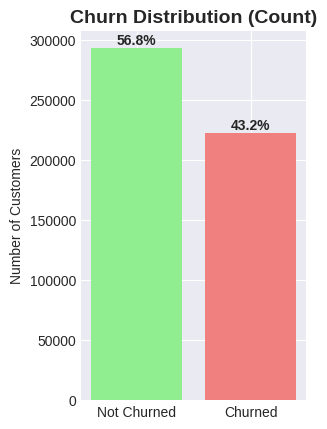

In [60]:
#Count plot
plt.subplot(1, 2, 1)
churn_counts = df['Churn'].value_counts()
colors = ['lightgreen', 'lightcoral']
plt.bar(['Not Churned', 'Churned'], churn_counts.values, color=colors)
plt.title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')

for i, count in enumerate(churn_counts.values):
    percentage = (count / len(df)) * 100
    plt.text(i, count + max(churn_counts.values)*0.01,
             f'{percentage:.1f}%', ha='center', fontweight='bold')

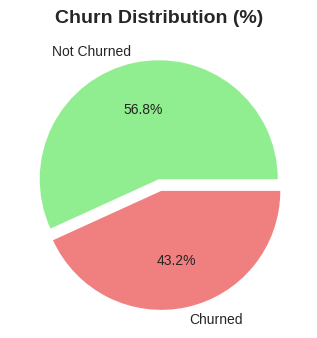

In [61]:
#Pie chart
plt.subplot(1, 2, 2)
plt.pie(churn_counts.values, labels=['Not Churned', 'Churned'],
        autopct='%1.1f%%', colors=colors, explode=[0, 0.1])
plt.title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

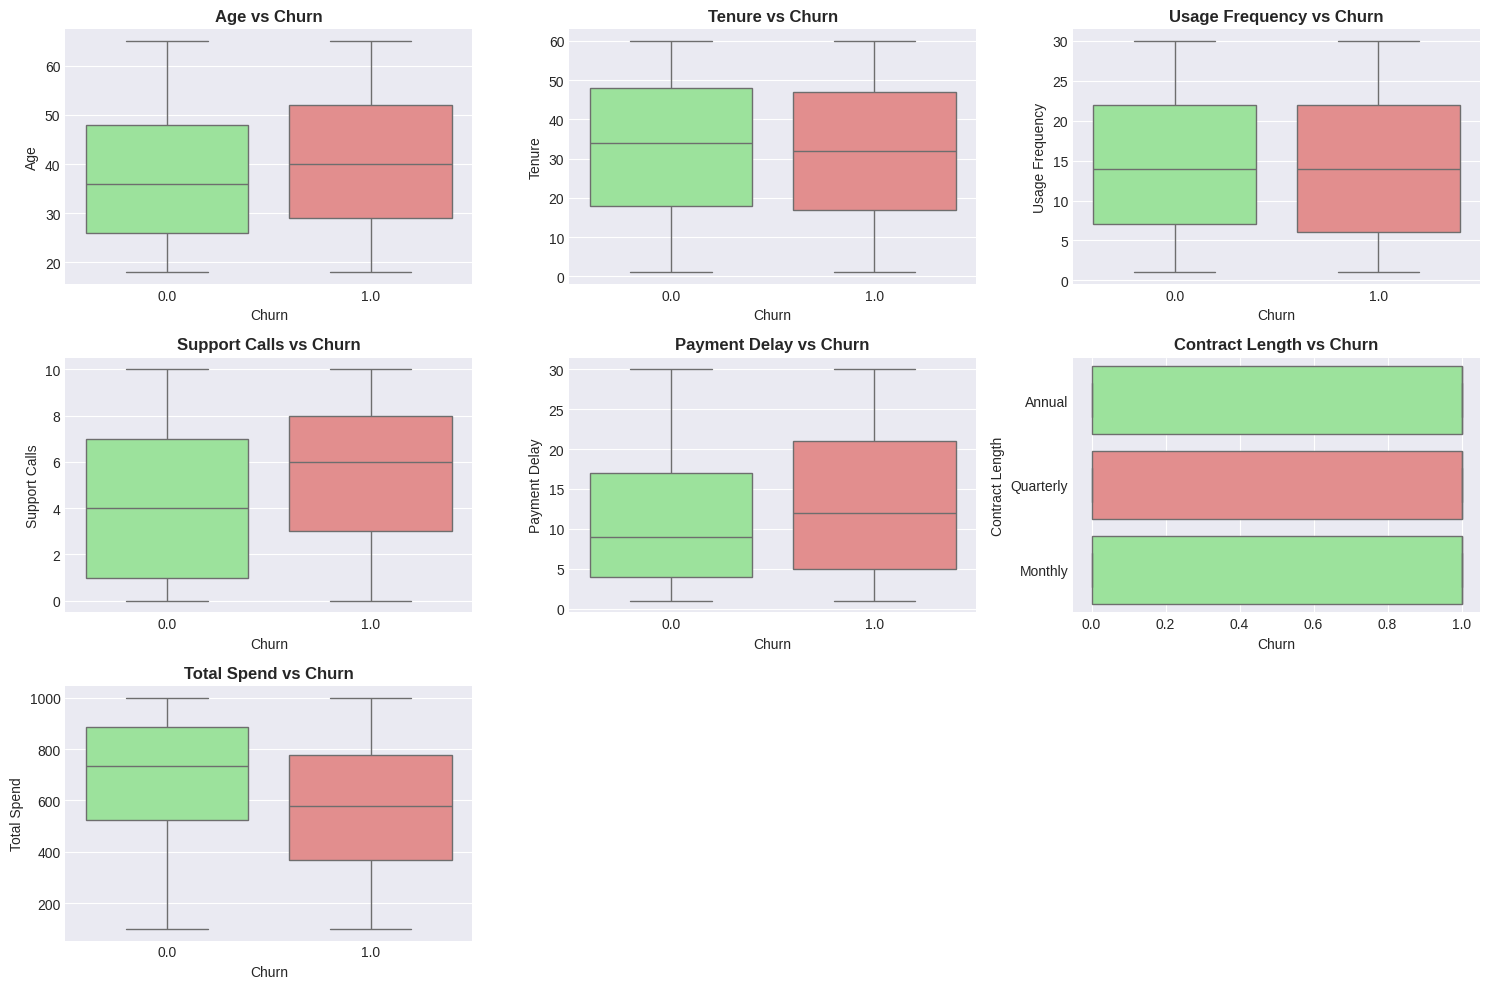

In [62]:
#Analyze numerical features vs churn
numerical_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                      'Payment Delay', 'Contract Length', 'Total Spend']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Churn', y=feature, data=df, palette=colors)
    plt.title(f'{feature} vs Churn', fontweight='bold')

plt.tight_layout()
plt.show()

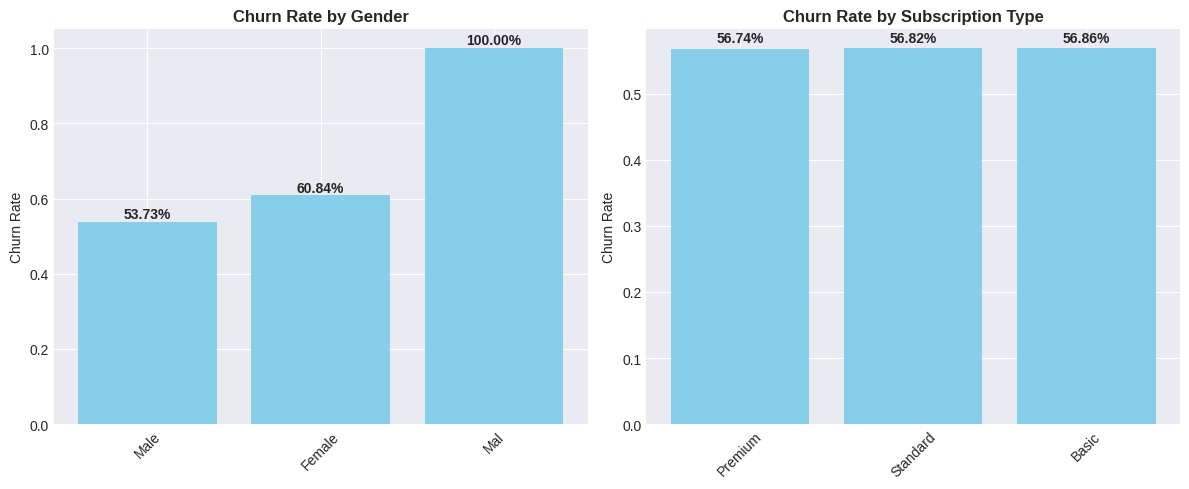

In [63]:
#Analyze categorical features
categorical_features = ['Gender', 'Subscription Type']

plt.figure(figsize=(12, 5))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, 2, i)

    churn_rate = df.groupby(feature)['Churn'].mean().sort_values()

    bars = plt.bar(range(len(churn_rate)), churn_rate.values, color='skyblue')
    plt.xticks(range(len(churn_rate)), churn_rate.index, rotation=45)
    plt.title(f'Churn Rate by {feature}', fontweight='bold')
    plt.ylabel('Churn Rate')

    for bar, value in zip(bars, churn_rate.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{value:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [65]:
# Step 5.1: Separate features and target
X = df.drop('Churn', axis=1)  # Features
y = df['Churn']  # Target

In [68]:
X.shape

(516278, 10)

In [69]:
y.shape

(516278,)

In [70]:
#Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [71]:
categorical_cols

['Gender', 'Subscription Type', 'Contract Length']

In [72]:
numerical_cols

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

In [73]:
label_encoders = {}

In [74]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  {col}: {list(le.classes_)}")

  Gender: ['Female', 'Mal', 'Male']
  Subscription Type: ['Basic', 'Premium', 'Standard']
  Contract Length: ['Annual', 'Monthly', 'Quarterly']


In [75]:
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [76]:
pd.DataFrame(X, columns=X.columns).head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,0.288231,2,0.575585,-0.730735,0.956922,1.470760,2,0,-1.989743,0.773931
1,-1.220942,0,1.639473,-0.276400,0.023974,-1.095913,0,0,0.905856,0.064229
2,1.420111,2,1.284844,-0.503568,-1.530940,-0.279244,2,2,-0.790744,1.247065
3,0.590066,2,0.161851,-0.957903,1.267905,1.354093,1,2,0.072215,0.892214
4,-0.994566,2,0.752900,0.745855,-0.287009,-1.329247,0,2,0.570759,-0.408906


In [77]:
f"Min: {X.min().min():.2f}, Max: {X.max().max():.2f}"

'Min: -2.14, Max: 2.05'

In [78]:
y.value_counts()

,count
Churn,
1.0,293286
0.0,222992


In [79]:
f"Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1"

'Imbalance ratio: 0.76:1'

In [82]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train Churn: {y_train.value_counts().to_dict()}")

Train: (469257, 10), Test: (117315, 10)
Train Churn: {1.0: 234629, 0.0: 234628}


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Important Features')
plt.show()

print("Top 5 Features:")
print(feature_importance.head(5))

In [ ]:
model_package = {
    'model': model,
    'label_encoders': label_encoders,
    'scaler': scaler,
    'features': X.columns.tolist()
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Model saved as 'churn_model.pkl'")

In [ ]:
def predict_churn(customer_data):
    with open('churn_model.pkl', 'rb') as f:
        package = pickle.load(f)

    model = package['model']
    label_encoders = package['label_encoders']
    scaler = package['scaler']

    input_df = pd.DataFrame([customer_data])

    for col, encoder in label_encoders.items():
        if col in input_df.columns:
            try:
                input_df[col] = encoder.transform(input_df[col])
            except:
                input_df[col] = encoder.transform([encoder.classes_[0]])

    numeric_cols = input_df.select_dtypes(include=[np.number]).columns
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return {
        'churn': bool(prediction),
        'probability': float(probability),
        'risk': 'High' if probability > 0.7 else 'Medium' if probability > 0.4 else 'Low'
    }

In [ ]:
test_customer = {
    'Age': 35,
    'Gender': 'Male',
    'Tenure': 12,
    'Usage Frequency': 15,
    'Support Calls': 2,
    'Payment Delay': 5,
    'Subscription Type': 'Premium',
    'Contract Length': 24,
    'Total Spend': 959.88
}

result = predict_churn(test_customer)
print("\n🔮 Prediction Result:")
print(f"Will Churn: {result['churn']}")
print(f"Probability: {result['probability']:.2%}")
print(f"Risk Level: {result['risk']}")

In [ ]:
print("\n📊 BUSINESS INSIGHTS")
print("=" * 40)

churn_rate = df['Churn'].mean()
print(f"Overall Churn Rate: {churn_rate:.1%}")

if 'PaymentDelay' in df.columns:
    high_delay_churn = df[df['PaymentDelay'] > df['PaymentDelay'].median()]['Churn'].mean()
    print(f"High Payment Delay Churn: {high_delay_churn:.1%}")

if 'SupportCalls' in df.columns:
    high_calls_churn = df[df['SupportCalls'] > df['SupportCalls'].median()]['Churn'].mean()
    print(f"High Support Calls Churn: {high_calls_churn:.1%}")

print("\n🎯 RECOMMENDATIONS:")
print("1. Focus on customers with payment delays")
print("2. Improve support to reduce call frequency")
print("3. Target customers with short tenure")

In [ ]:
from google.colab import files
files.download('churn_model.pkl')
print("📥 Model downloaded!")